In [1]:
from robust_plotter import *
from tests.indexador_2026 import indexar_problema

import os

# Path to your experiment folder
log_dir = r"D:\Thiago Artur\OneDrive\Documentos\2025.2\Pesquisa\Rodadas\Problema 4\Resultados"
out_dir = os.path.join(log_dir, "Graph")
os.makedirs(out_dir, exist_ok=True)

# define padrão de subpasta do diretório
def return_path(algo, index):
    return os.path.join(log_dir, algo, f"Conjunto {index}")

# Problem data
dadosp = indexar_problema(4)

# Filtrar conjuntos (boxplot)
filter_sets = {
    "GA": [1],
    "PSO": [3],
    "BO": [2]
}

algos = list(filter_sets.keys())
logs_dir = {
    algo: return_path(algo, filter_sets[algo][0]) for algo in algos
}

In [ ]:
from data.compile import compile_convergence_history

for algo, sets in filter_sets.items():
    algo_dir = os.path.join(log_dir, algo)

    for set in sets:
        conjunto_nome = f"Conjunto {set}"
        set_dir = os.path.join(algo_dir, conjunto_nome)

        compile_convergence_history(algo, dadosp.expected_values, set_dir, conjunto_nome)


In [2]:
plot = Plotter(log_dir)

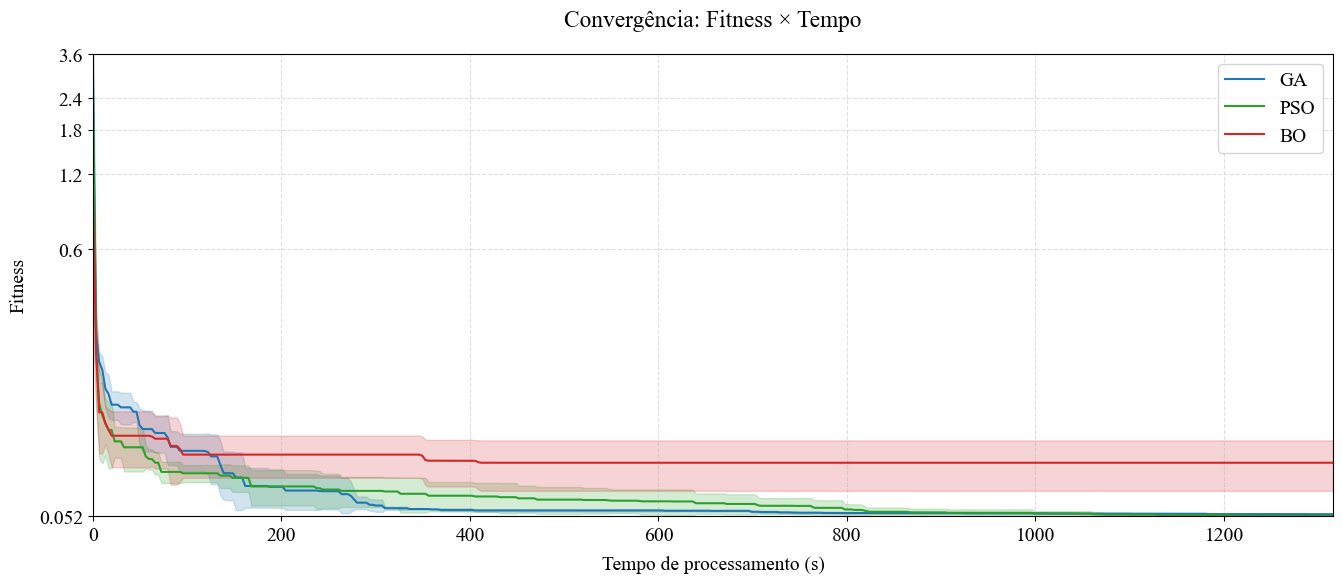

In [3]:
plot.plot_convergence_vs_time_logs(algos, logs_dir)

In [ ]:
plot.plot_all_results(param_keys=dadosp.keys, key_to_name=dadosp.key_to_name, param_expected_values=dadosp.expected_values, param_search_space=dadosp.search_spaces, filter_sets=filter_sets)